In [1]:
%cd ~/workspace/ecoevodevox/
%env CUDA_VISIBLE_DEVICES=3

from qdax.core.containers.mapelites_repertoire import compute_euclidean_centroids
from qdax.utils.plotting import plot_2d_map_elites_repertoire
from src.evo.qd_rand import *
from src.utils.viz import render_developmental_trajectory, plot_repertoire
import matplotlib.pyplot as plt
import pickle
import numpy as np
from sklearn.decomposition import PCA
from sklearn.cluster import HDBSCAN, KMeans

/home/erwan/workspace/ecoevodevox
env: CUDA_VISIBLE_DEVICES=3


# Utils

In [2]:
def plot_dev(traj):
    fig, axs = plt.subplots(2, 1, height_ratios=[0.8, 0.2])
    render_developmental_trajectory(traj, ax=axs[0], s=20, cmap="Blues")
    sizes = traj.mask.sum(-1)
    axs[1].plot(sizes)
    return fig, axs

# Random explo

In [3]:
rand_params = dict(init_neurons=1, max_neurons=32, dev_iters=100, migratory_genes=8, signalling_genes=4,
                   wiring_model="mlp")

fctry, model = make_rand_genotype_fctry(rand_params)
_, model_sttcs = eqx.partition(model, eqx.is_array)

In [4]:
@jax.jit
def make_networks(key):
    k1, k2, k3 = jr.split(key, 3)
    rand = eqx.combine(fctry(k1), model_sttcs)
    net = rand.init_embryo(k2)
    net, traj = rand.do_migration(net, k3, with_trace=True)
    return net, traj

In [5]:
nets, trajs = jax.vmap(make_networks)(jr.split(jr.key(101), 16))

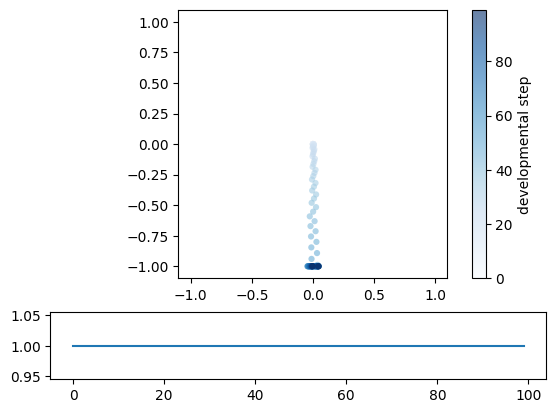

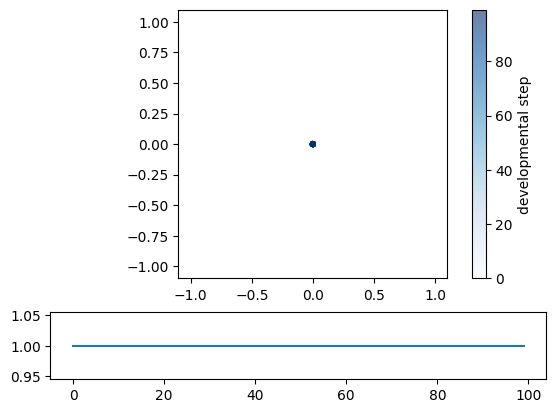

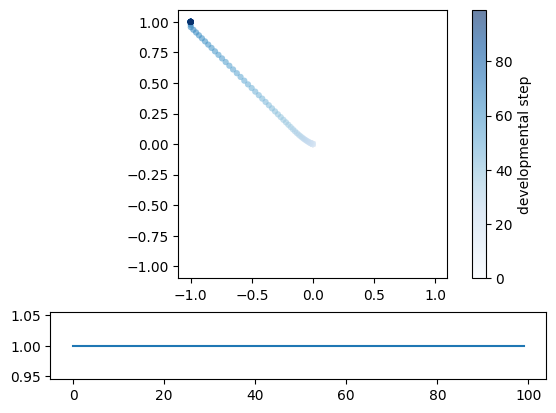

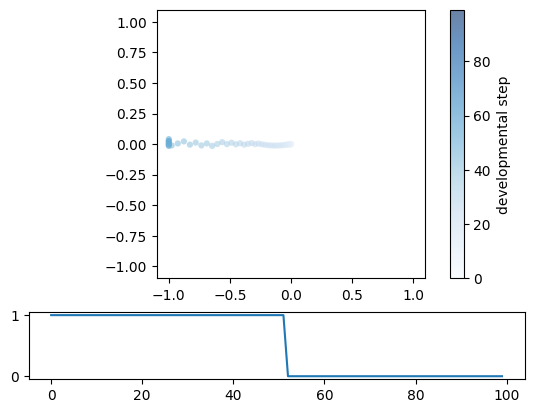

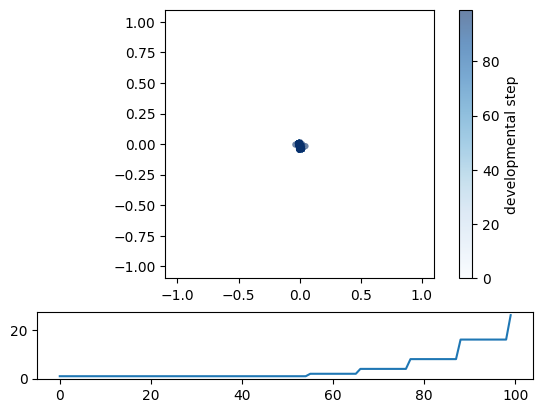

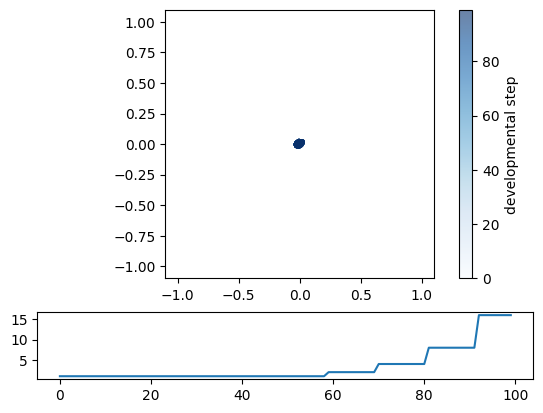

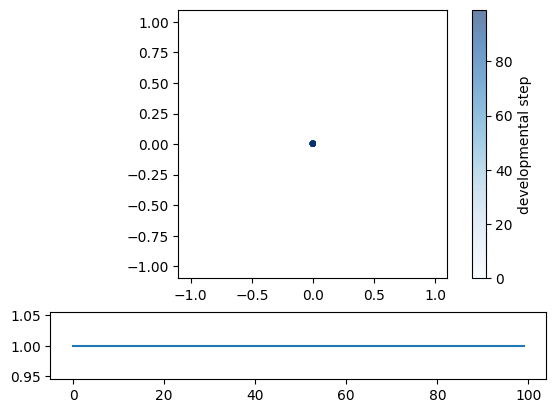

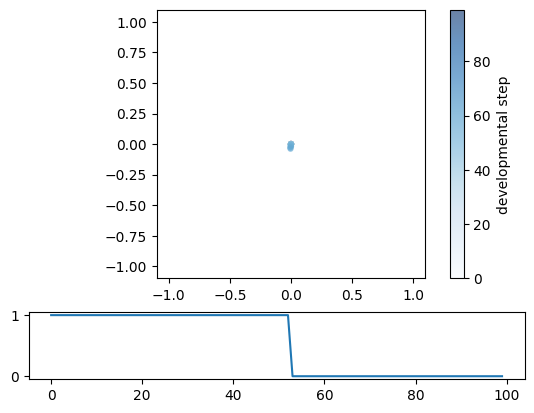

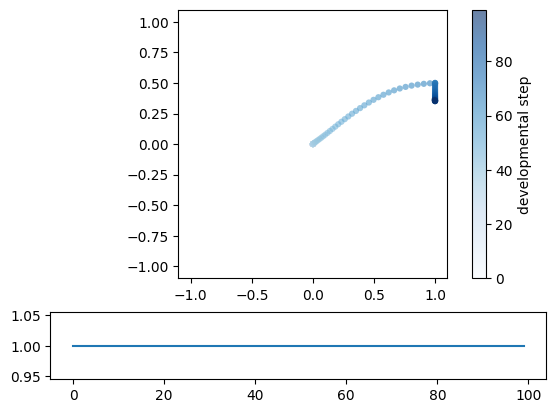

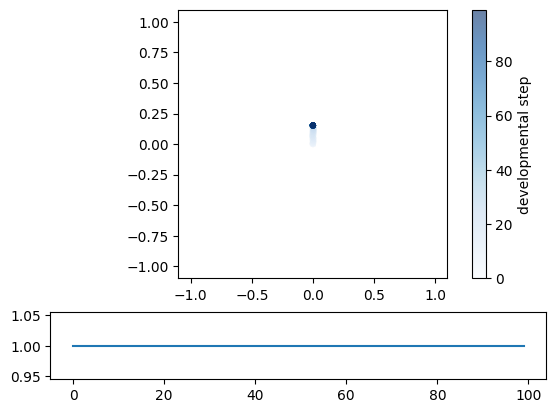

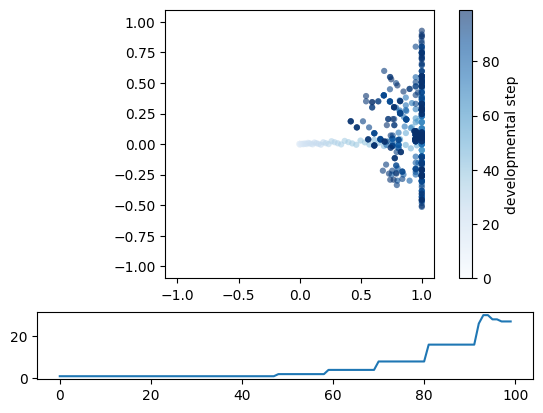

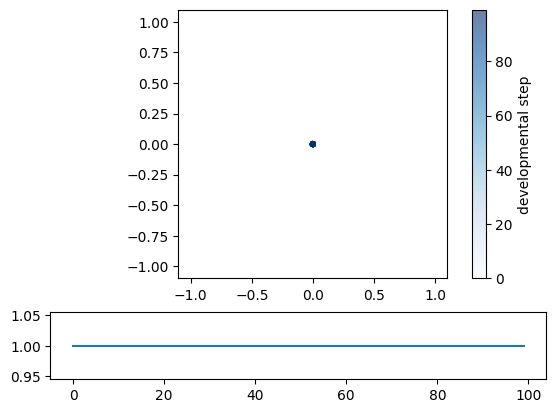

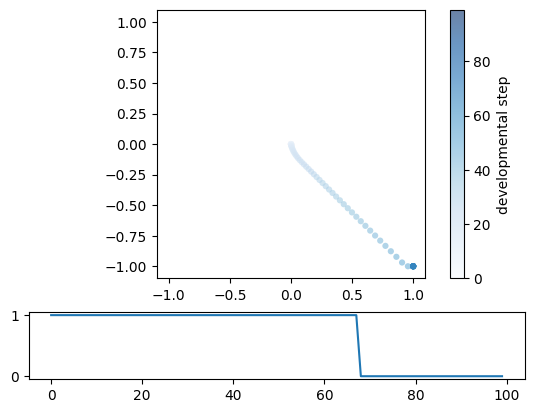

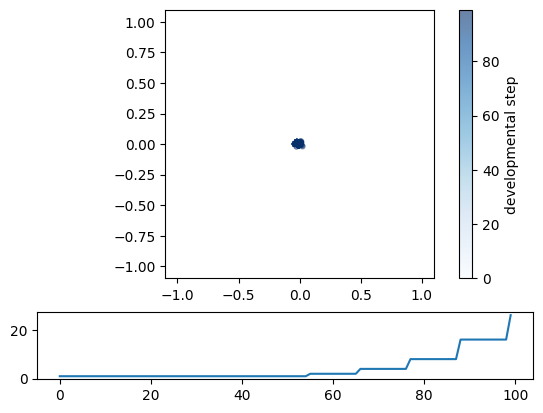

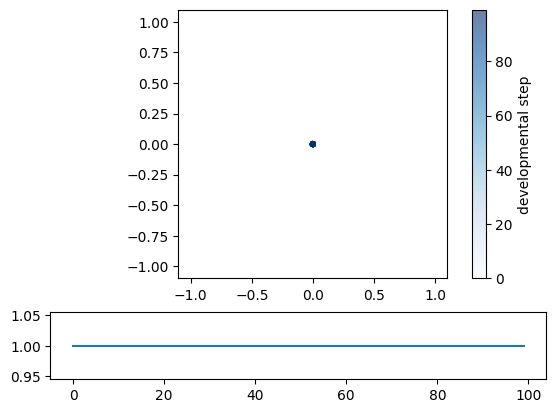

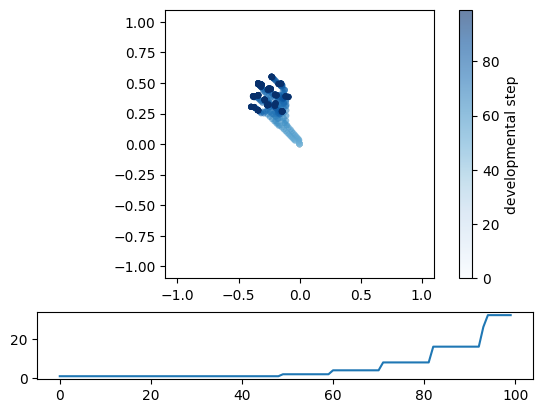

In [6]:
for i in range(16):
    traj = jax.tree.map(lambda x: x[i], trajs["state"])
    fig, ax = plot_dev(traj)
    plt.show()

In [8]:
traj.x

Array([[[nan, nan],
        [ 0.,  0.],
        [ 0.,  0.],
        ...,
        [ 0.,  0.],
        [ 0.,  0.],
        [ 0.,  0.]],

       [[nan, nan],
        [ 0.,  0.],
        [ 0.,  0.],
        ...,
        [ 0.,  0.],
        [ 0.,  0.],
        [ 0.,  0.]],

       [[nan, nan],
        [ 0.,  0.],
        [ 0.,  0.],
        ...,
        [ 0.,  0.],
        [ 0.,  0.],
        [ 0.,  0.]],

       ...,

       [[nan, nan],
        [ 0.,  0.],
        [ 0.,  0.],
        ...,
        [ 0.,  0.],
        [ 0.,  0.],
        [ 0.,  0.]],

       [[nan, nan],
        [ 0.,  0.],
        [ 0.,  0.],
        ...,
        [ 0.,  0.],
        [ 0.,  0.],
        [ 0.,  0.]],

       [[nan, nan],
        [ 0.,  0.],
        [ 0.,  0.],
        ...,
        [ 0.,  0.],
        [ 0.,  0.],
        [ 0.,  0.]]], dtype=float32)

# Size and Diversity

In [11]:
SEED = 0

MODEL_KWARGS = dict(          # -> RAND_CTRNN(**MODEL_KWARGS, key=...)
    init_neurons=1,
    max_neurons=64,
    dev_iters=200,            # development length
    max_mitosis=10,
    mitotic_factor_threshold=5.0,
    apoptosis_factor_threshold=5.0,
    gene_noise_scale=0.0,     # >0 makes development stochastic
    position_noise_scale=0.0,
)

DESCRIPTORS = ["nb_neurons", "connectivity"]   # keys of `descriptor_fns`
GRID        = [32, 32]                         # one entry per descriptor
N           = 1024                               # offspring / iteration
TRAIN_STEPS = 10_000
SIGMA_MUT, MUT_RATE = 0.03, 1.0
ACTIVITY_STEPS, INPUT_SCALE = 100, 0.1         # fitness rollout

REPERTOIRE_KWARGS = dict(     # defaults = vanilla MAP-Elites
    max_age=128,             # age elites out after this many additions
    replace_probability=0.0,  # chance an aged elite is evictable
    extinction_probability=0.0,
)

genotype_fctry, model = make_rand_genotype_fctry(MODEL_KWARGS)
mins, maxs = descriptor_bounds(DESCRIPTORS)
centroids  = compute_euclidean_centroids(GRID, mins, maxs)

scoring_fn  = make_rand_scoring_fn(model, DESCRIPTORS,
                                   activity_steps=ACTIVITY_STEPS,
                                   input_scale=INPUT_SCALE)
mutation_fn = ContinuousMutation(sigma_mut=SIGMA_MUT, mut_rate=MUT_RATE)

train = make_train_fn(
    genotype_fctry, scoring_fn, mutation_fn, centroids,
    N=N, train_steps=TRAIN_STEPS,
    nb_init_genotypes=N,   # genotypes used to seed the archive
    nb_devices=None,       # None -> all devices; N must divide evenly
    return_trace=False,
    verbose=False,         # True -> jax.debug.print metrics each iteration
    repertoire_kwargs=REPERTOIRE_KWARGS,
)

In [ ]:
state, trace = train(jr.key(SEED))
repertoire = state.repertoire
print("final:", jax.tree.map(float, qd_metrics(repertoire)))

In [ ]:
with open(f"data/rand_qd/sizee_conn.pkl", "wb") as file:
    pickle.dump([state, trace], file)

In [ ]:
with open(f"data/rand_qd/sizee_conn.pkl", "rb") as file:
    state, trace = pickle.load(file)

<Axes: >

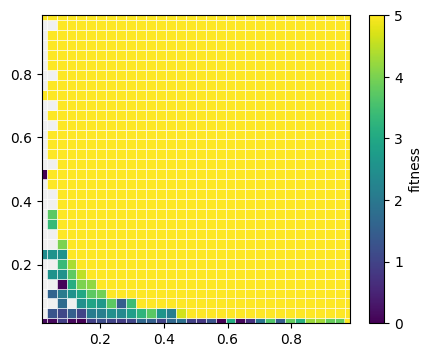

In [ ]:
plot_repertoire(state.repertoire)

# Left-Right

In [ ]:
def _left_neurons(net, model):
    is_left = (net.x[:,0] < -0.9) & net.mask
    return is_left.mean()

def _right_neurons(net, model):
    is_left = (net.x[:,0] > 0.9) & net.mask
    return is_left.mean()

descriptor_fns["left_neurons"] = (_left_neurons, 0.0, 1.0)
descriptor_fns["right_neurons"] = (_right_neurons, 0.0, 1.0)

In [ ]:
SEED = 0

MODEL_KWARGS = dict(          # -> RAND_CTRNN(**MODEL_KWARGS, key=...)
    init_neurons=1,
    max_neurons=64,
    dev_iters=200,            # development length
    max_mitosis=10,
    mitotic_factor_threshold=5.0,
    apoptosis_factor_threshold=5.0,
    gene_noise_scale=0.0,     # >0 makes development stochastic
    position_noise_scale=0.0,
)

DESCRIPTORS = ["left_neurons", "right_neurons"]   # keys of `descriptor_fns`
GRID        = [32, 32]                         # one entry per descriptor
N           = 1024                               # offspring / iteration
TRAIN_STEPS = 4096
SIGMA_MUT, MUT_RATE = 0.03, 1.0
ACTIVITY_STEPS, INPUT_SCALE = 100, 0.1         # fitness rollout

REPERTOIRE_KWARGS = dict(     # defaults = vanilla MAP-Elites
    max_age=128,             # age elites out after this many additions
    replace_probability=0.0,  # chance an aged elite is evictable
    extinction_probability=0.0,
)

genotype_fctry, model = make_rand_genotype_fctry(MODEL_KWARGS)
mins, maxs = descriptor_bounds(DESCRIPTORS)
centroids  = compute_euclidean_centroids(GRID, mins, maxs)

scoring_fn  = make_rand_scoring_fn(model, DESCRIPTORS,
                                   activity_steps=ACTIVITY_STEPS,
                                   input_scale=INPUT_SCALE)
mutation_fn = ContinuousMutation(sigma_mut=SIGMA_MUT, mut_rate=MUT_RATE)

train = make_train_fn(
    genotype_fctry, scoring_fn, mutation_fn, centroids,
    N=N, train_steps=TRAIN_STEPS,
    nb_init_genotypes=N,   # genotypes used to seed the archive
    nb_devices=None,       # None -> all devices; N must divide evenly
    return_trace=False,
    verbose=False,         # True -> jax.debug.print metrics each iteration
    repertoire_kwargs=REPERTOIRE_KWARGS,
)

In [ ]:
state, trace = train(jr.key(SEED))
repertoire = state.repertoire
print("final:", jax.tree.map(float, qd_metrics(repertoire)))

final: {'coverage': 0.51953125, 'max_fitness': 5.000000476837158, 'mean_fitness': 5.000000953674316, 'nb_elites': 532.0, 'qd_score': 2660.00048828125}


In [ ]:
with open(f"data/rand_qd/left_right.pkl", "wb") as file:
    pickle.dump([state, trace], file)

<Axes: >

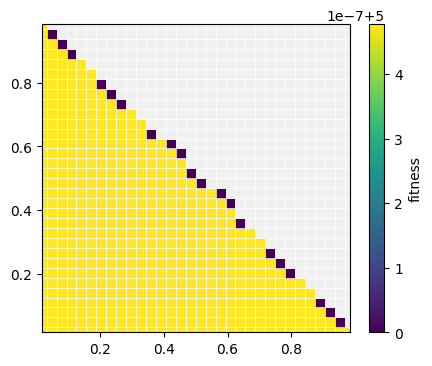

In [ ]:
plot_repertoire(state.repertoire)

elite fitness 5.000000476837158 | descriptors [0.234375 0.234375]


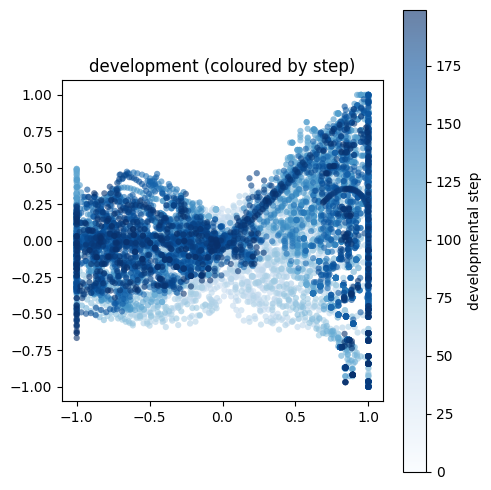

In [ ]:
occ = np.asarray(repertoire.is_occupied())
cen = np.asarray(repertoire.centroids)
fit = np.asarray(repertoire.fitnesses)

target_bd = np.asarray([0.25, 0.25])
best = int(jnp.argmin(np.where(repertoire.is_occupied(), np.linalg.norm(repertoire.descriptors - target_bd[None], axis=-1), jnp.inf)))
elite = jax.tree.map(lambda x: x[best], repertoire.genotypes)
print("elite fitness", float(fit[best]), "| descriptors", cen[best])

_, static = eqx.partition(model, eqx.is_array)
elite_model = eqx.combine(elite, static)          # genotype -> runnable RAND_CTRNN

embryo = elite_model.init_embryo(jr.key(1))
final_state, dev_trace = eqx.filter_jit(elite_model.do_migration)(embryo, jr.key(2))
#   NOTE: use eqx.filter_jit, not jax.jit -- the module holds arrays and won't hash.

fig, axes = plt.subplots(1, 1, figsize=(5,5))
render_developmental_trajectory(dev_trace["state"], ax=axes, every=1,
                                title="development (coloured by step)", cmap="Blues", s=20)
#render_network(elite_model.make_network(final_state), ax=axes[1])
fig.tight_layout()

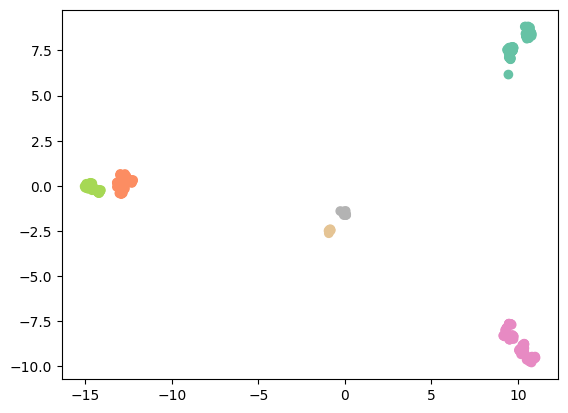

In [ ]:
all_genotypes = jax.tree.map(lambda x: x[repertoire.is_occupied()], repertoire.genotypes)

all_genotypes_flat = np.asarray(jax.vmap(lambda tree: ravel_pytree(tree)[0])(all_genotypes))

all_genotypes_flat.shape
pca = PCA(n_components=16)
pcs = pca.fit_transform(all_genotypes_flat)

kmeans = KMeans(n_clusters=6)
clusters = kmeans.fit_predict(pcs)

plt.scatter(*pcs[:,:2].T, c=clusters, cmap="Set2")
plt.show()

<Axes: >

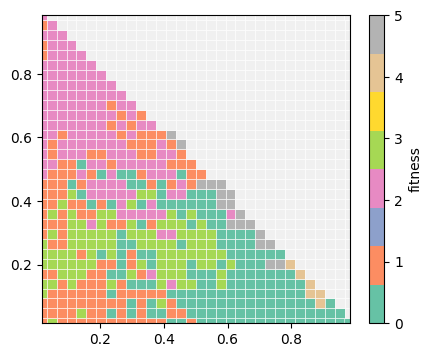

In [ ]:
new_fit = np.copy(fit)
new_fit[occ] = clusters
plot_repertoire(repertoire.replace(fitnesses=new_fit), cmap="Set2")

# Propellers and direction

In [3]:
def _symmetry(net, rollout, key): 
    ln = _left_neurons(net, None)
    rn = _right_neurons(net, None)

    return jnp.exp(-((ln-rn)**2))

def _propellers(net, model):
    return jnp.mean((net.x[:,1]<-0.9) & (jnp.abs(net.x[:,0])<0.5) & net.mask)

fitness_fns["symmetry"] = _symmetry
descriptor_fns["propellers"] = (_propellers, 0., 1.)

In [ ]:
SEED = 0

MODEL_KWARGS = dict(          # -> RAND_CTRNN(**MODEL_KWARGS, key=...)
    init_neurons=1,
    max_neurons=64,
    dev_iters=200,            # development length
    max_mitosis=10,
    mitotic_factor_threshold=5.0,
    apoptosis_factor_threshold=5.0,
    gene_noise_scale=0.0,     # >0 makes development stochastic
    position_noise_scale=0.0,
)

FITNESS = "symmetry"
DESCRIPTORS = ["propellers", "right_neurons"]   # keys of `descriptor_fns`
GRID        = [32, 32]                         # one entry per descriptor
N           = 1024                               # offspring / iteration
TRAIN_STEPS = 4096
SIGMA_MUT, MUT_RATE = 0.03, 1.0
ACTIVITY_STEPS, INPUT_SCALE = 100, 0.1         # fitness rollout

REPERTOIRE_KWARGS = dict(     # defaults = vanilla MAP-Elites
    max_age=128,             # age elites out after this many additions
    replace_probability=0.0,  # chance an aged elite is evictable
    extinction_probability=0.0,
)

genotype_fctry, model = make_rand_genotype_fctry(MODEL_KWARGS)
mins, maxs = descriptor_bounds(DESCRIPTORS)
centroids  = compute_euclidean_centroids(GRID, mins, maxs)

scoring_fn  = make_rand_scoring_fn(model, DESCRIPTORS,
                                   activity_steps=ACTIVITY_STEPS,
                                   input_scale=INPUT_SCALE,
                                   fitness=FITNESS)
mutation_fn = ContinuousMutation(sigma_mut=SIGMA_MUT, mut_rate=MUT_RATE)

train = make_train_fn(
    genotype_fctry, scoring_fn, mutation_fn, centroids,
    N=N, train_steps=TRAIN_STEPS,
    nb_init_genotypes=N,   # genotypes used to seed the archive
    nb_devices=None,       # None -> all devices; N must divide evenly
    return_trace=False,
    verbose=False,         # True -> jax.debug.print metrics each iteration
    repertoire_kwargs=REPERTOIRE_KWARGS,
)

In [ ]:
state, trace = train(jr.key(SEED))
repertoire = state.repertoire
print("final:", jax.tree.map(float, qd_metrics(repertoire)))

final: {'coverage': 0.51953125, 'max_fitness': 1.0, 'mean_fitness': 0.927558422088623, 'nb_elites': 532.0, 'qd_score': 493.4610595703125}


In [9]:
with open(f"data/rand_qd/prop_and_dir.pkl", "wb") as file:
    pickle.dump([state, trace], file)

<Axes: >

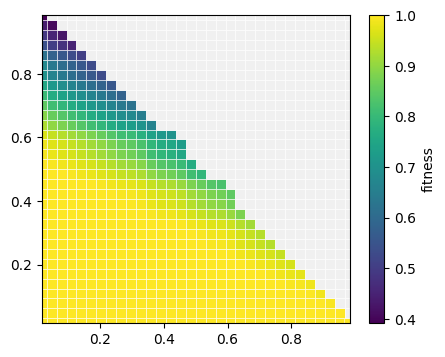

In [ ]:
plot_repertoire(state.repertoire)

elite fitness 1.0 | descriptors [0.515625 0.046875]


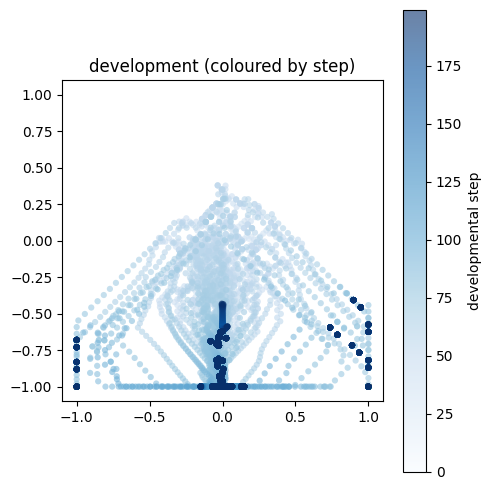

In [ ]:
occ = np.asarray(repertoire.is_occupied())
cen = np.asarray(repertoire.centroids)
fit = np.asarray(repertoire.fitnesses)

target_bd = np.asarray([0.5, 0.05])
best = int(jnp.argmin(np.where(repertoire.is_occupied(), np.linalg.norm(repertoire.descriptors - target_bd[None], axis=-1), jnp.inf)))
elite = jax.tree.map(lambda x: x[best], repertoire.genotypes)
print("elite fitness", float(fit[best]), "| descriptors", cen[best])

_, static = eqx.partition(model, eqx.is_array)
elite_model = eqx.combine(elite, static)          # genotype -> runnable RAND_CTRNN

embryo = elite_model.init_embryo(jr.key(0))
final_state, dev_trace = eqx.filter_jit(elite_model.do_migration)(embryo, jr.key(2))
#   NOTE: use eqx.filter_jit, not jax.jit -- the module holds arrays and won't hash.

fig, axes = plt.subplots(1, 1, figsize=(5,5))
render_developmental_trajectory(dev_trace["state"], ax=axes, every=1,
                                title="development (coloured by step)", cmap="Blues", s=20)
#render_network(elite_model.make_network(final_state), ax=axes[1])
fig.tight_layout()

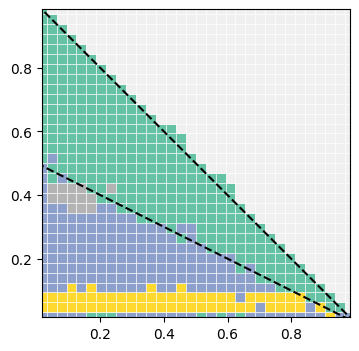

In [ ]:
all_genotypes = jax.tree.map(lambda x: x[repertoire.is_occupied()], repertoire.genotypes)

all_genotypes_flat = np.asarray(jax.vmap(lambda tree: ravel_pytree(tree)[0])(all_genotypes))

all_genotypes_flat.shape
pca = PCA(n_components=16)
pcs = pca.fit_transform(all_genotypes_flat)

kmeans = KMeans(n_clusters=4)
clusters = kmeans.fit_predict(pcs[:,:2])

plt.scatter(*pcs[:,:2].T, c=clusters, cmap="Set2")
plt.show()

new_fit = np.copy(fit)
new_fit[occ] = clusters
ax = plot_repertoire(repertoire.replace(fitnesses=new_fit), cmap="Set2", colorbar=False)

f = lambda x: 0.5 - x/2
ax.plot([0, 1], [f(0), f(1)], color="k", linestyle="--")

f = lambda x: 1. - x
ax.plot([0, 1], [f(0), f(1)], color="k", linestyle="--")

# nb neurons and diversity

In [ ]:
def _transcription_entropy(net, model):
    return global_gene_expression_entropy(net, bins=4, normalize=True)

def _rand_fitness(net, rol, key):
    return jr.normal(key)

descriptor_fns["entropy"] = (_transcription_entropy, 0., 1.)
fitness_fns["random"] = _rand_fitness

In [ ]:
SEED = 0

MODEL_KWARGS = dict(          # -> RAND_CTRNN(**MODEL_KWARGS, key=...)
    init_neurons=1,
    max_neurons=64,
    dev_iters=200,            # development length
    max_mitosis=10,
    mitotic_factor_threshold=5.0,
    apoptosis_factor_threshold=5.0,
    gene_noise_scale=0.0,     # >0 makes development stochastic
    position_noise_scale=0.0,
)

FITNESS = "random"
DESCRIPTORS = ["nb_neurons", "entropy"]   # keys of `descriptor_fns`
GRID        = [32, 32]                         # one entry per descriptor
N           = 1024                               # offspring / iteration
TRAIN_STEPS = 2048
SIGMA_MUT, MUT_RATE = 0.03, 1.0
ACTIVITY_STEPS, INPUT_SCALE = 100, 0.1         # fitness rollout

REPERTOIRE_KWARGS = dict(     # defaults = vanilla MAP-Elites
    max_age=128,             # age elites out after this many additions
    replace_probability=0.0,  # chance an aged elite is evictable
    extinction_probability=0.0,
)

genotype_fctry, model = make_rand_genotype_fctry(MODEL_KWARGS)
mins, maxs = descriptor_bounds(DESCRIPTORS)
centroids  = compute_euclidean_centroids(GRID, mins, maxs)

scoring_fn  = make_rand_scoring_fn(model, DESCRIPTORS,
                                   activity_steps=ACTIVITY_STEPS,
                                   input_scale=INPUT_SCALE,
                                   fitness=FITNESS)
mutation_fn = ContinuousMutation(sigma_mut=SIGMA_MUT, mut_rate=MUT_RATE)

train = make_train_fn(
    genotype_fctry, scoring_fn, mutation_fn, centroids,
    N=N, train_steps=TRAIN_STEPS,
    nb_init_genotypes=N,   # genotypes used to seed the archive
    nb_devices=None,       # None -> all devices; N must divide evenly
    return_trace=False,
    verbose=False,         # True -> jax.debug.print metrics each iteration
    repertoire_kwargs=REPERTOIRE_KWARGS,
)

In [ ]:
state, trace = train(jr.key(SEED))
repertoire = state.repertoire
print("final:", jax.tree.map(float, qd_metrics(repertoire)))

final: {'coverage': 0.392578125, 'max_fitness': 4.273387908935547, 'mean_fitness': 2.6212430000305176, 'nb_elites': 402.0, 'qd_score': 1053.73974609375}


<Axes: >

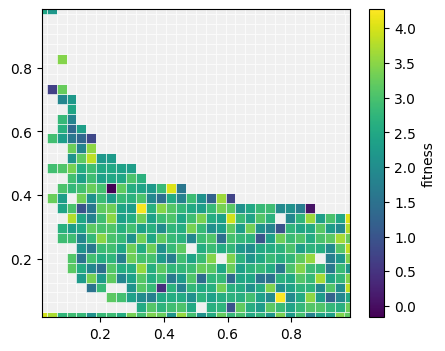

In [ ]:
plot_repertoire(state.repertoire)

elite fitness 2.774811029434204 | descriptors [0.796875 0.203125]
49


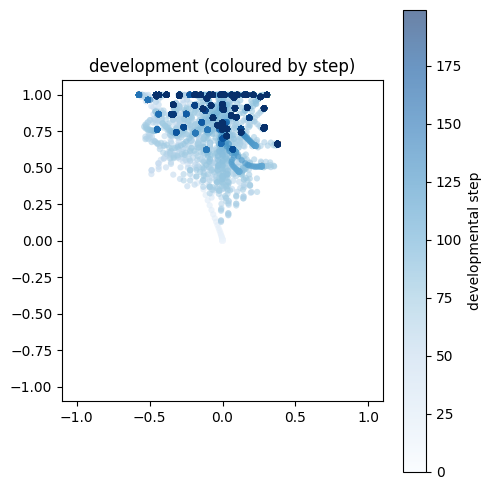

In [ ]:
occ = np.asarray(repertoire.is_occupied())
cen = np.asarray(repertoire.centroids)
fit = np.asarray(repertoire.fitnesses)

target_bd = np.asarray([0.8, 0.2])
best = int(jnp.argmin(np.where(repertoire.is_occupied(), np.linalg.norm(repertoire.descriptors - target_bd[None], axis=-1), jnp.inf)))
elite = jax.tree.map(lambda x: x[best], repertoire.genotypes)
print("elite fitness", float(fit[best]), "| descriptors", cen[best])

_, static = eqx.partition(model, eqx.is_array)
elite_model = eqx.combine(elite, static)          # genotype -> runnable RAND_CTRNN

embryo = elite_model.init_embryo(jr.key(0))
final_state, dev_trace = eqx.filter_jit(elite_model.do_migration)(embryo, jr.key(2))
#   NOTE: use eqx.filter_jit, not jax.jit -- the module holds arrays and won't hash.
print(final_state.mask.sum())

fig, axes = plt.subplots(1, 1, figsize=(5,5))
render_developmental_trajectory(dev_trace["state"], ax=axes, every=1,
                                title="development (coloured by step)", cmap="Blues", s=20)
#render_network(elite_model.make_network(final_state), ax=axes[1])
fig.tight_layout()

# Dev. Plasticity

In [4]:
def _left_neurons(net, model):
    is_left = (net.x[:,0] < -0.9) & net.mask
    return is_left.mean()

def _right_neurons(net, model):
    is_left = (net.x[:,0] > 0.9) & net.mask
    return is_left.mean()

def _symmetry(net, rollout, key): 
    ln = _left_neurons(net, None)
    rn = _right_neurons(net, None)

    return jnp.exp(-((ln-rn)**2))

descriptor_fns["left_neurons"] = (_left_neurons, 0.0, 1.0)
descriptor_fns["right_neurons"] = (_right_neurons, 0.0, 1.0)

fitness_fns["symmetry"] = _symmetry

In [5]:
SEED = 0

MODEL_KWARGS = dict(          # -> RAND_CTRNN(**MODEL_KWARGS, key=...)
    init_neurons=1,
    max_neurons=64,
    dev_iters=200,            # development length
    max_mitosis=10,
    mitotic_factor_threshold=5.0,
    apoptosis_factor_threshold=5.0,
    gene_noise_scale=0.0,     # >0 makes development stochastic
    position_noise_scale=0.0,
)

FITNESS = "symmetry"
DESCRIPTOR = "left_neurons"   # keys of `descriptor_fns`
GRID        = [32,32]                         # one entry per descriptor
N           = 1024                               # offspring / iteration
TRAIN_STEPS = 4096
SIGMA_MUT, MUT_RATE = 0.05, 1.0
ACTIVITY_STEPS, INPUT_SCALE = 100, 0.1         # fitness rollout

REPERTOIRE_KWARGS = dict(     # defaults = vanilla MAP-Elites
    max_age=8,             # age elites out after this many additions
    replace_probability=0.0,  # chance an aged elite is evictable
    extinction_probability=0.0,
)

genotype_fctry, model = make_rand_genotype_fctry(MODEL_KWARGS)
centroids  = compute_euclidean_centroids(GRID, 0., 1.)

scoring_fn  = make_rand_plasticity_scoring_fn(model, DESCRIPTOR, (0., 1.), FITNESS)
mutation_fn = ContinuousMutation(sigma_mut=SIGMA_MUT, mut_rate=MUT_RATE)

train = make_train_fn(
    genotype_fctry, scoring_fn, mutation_fn, centroids,
    N=N, train_steps=TRAIN_STEPS,
    nb_init_genotypes=N,   # genotypes used to seed the archive
    nb_devices=None,       # None -> all devices; N must divide evenly
    return_trace=False,
    verbose=False,         # True -> jax.debug.print metrics each iteration
    repertoire_kwargs=REPERTOIRE_KWARGS,
)

In [6]:
state, trace = train(jr.key(SEED))
repertoire = state.repertoire
print("final:", jax.tree.map(float, qd_metrics(repertoire)))

final: {'coverage': 0.9150390625, 'max_fitness': 1.0, 'mean_fitness': 0.875170111656189, 'nb_elites': 937.0, 'qd_score': 820.034423828125}


<Axes: >

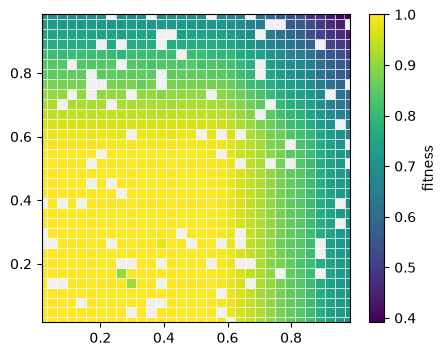

In [7]:
plot_repertoire(state.repertoire)

elite fitness 0.7753808498382568 | descriptors [0.796875 0.703125]


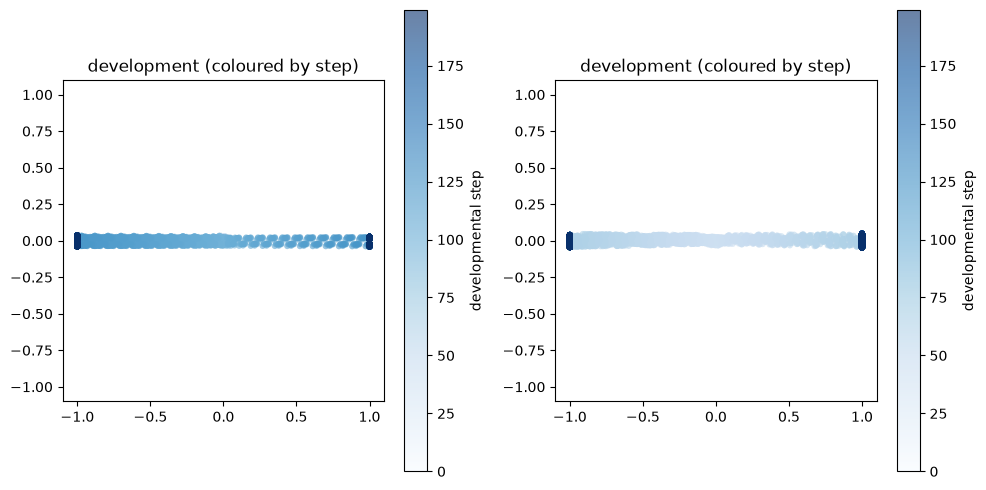

In [8]:
occ = np.asarray(repertoire.is_occupied())
cen = np.asarray(repertoire.centroids)
fit = np.asarray(repertoire.fitnesses)

target_bd = np.asarray([0.8, 0.7])
best = int(jnp.argmin(np.where(repertoire.is_occupied(), np.linalg.norm(repertoire.descriptors - target_bd[None], axis=-1), jnp.inf)))
elite = jax.tree.map(lambda x: x[best], repertoire.genotypes)
print("elite fitness", float(fit[best]), "| descriptors", cen[best])

_, static = eqx.partition(model, eqx.is_array)
elite_model = eqx.combine(elite, static)          # genotype -> runnable RAND_CTRNN

embryo = elite_model.init_embryo(jr.key(0))
embryo_a = embryo.replace(s=embryo.s.at[0,-1].set(0.0))
embryo_b = embryo.replace(s=embryo.s.at[0,-1].set(1.0))

final_state_a, dev_trace_a = eqx.filter_jit(elite_model.do_migration)(embryo_a, jr.key(2))
final_state_b, dev_trace_b = eqx.filter_jit(elite_model.do_migration)(embryo_b, jr.key(2))
#   NOTE: use eqx.filter_jit, not jax.jit -- the module holds arrays and won't hash.

fig, axes = plt.subplots(1, 2, figsize=(10,5))

render_developmental_trajectory(dev_trace_a["state"], ax=axes[0], every=1,
                                title="development (coloured by step)", cmap="Blues", s=20)

render_developmental_trajectory(dev_trace_b["state"], ax=axes[1], every=1,
                                title="development (coloured by step)", cmap="Blues", s=20)
#render_network(elite_model.make_network(final_state), ax=axes[1])
fig.tight_layout()

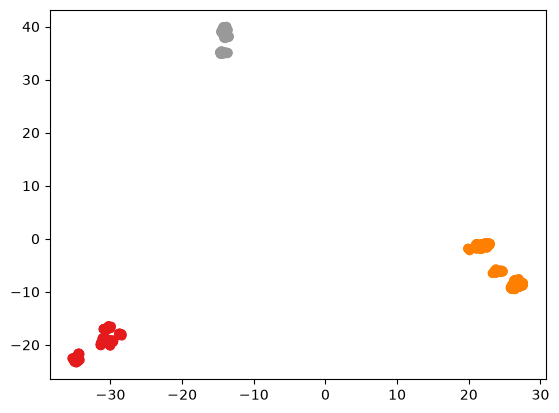

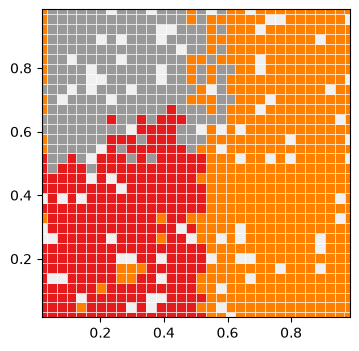

In [11]:
all_genotypes = jax.tree.map(lambda x: x[repertoire.is_occupied()], repertoire.genotypes)

all_genotypes_flat = np.asarray(jax.vmap(lambda tree: ravel_pytree(tree)[0])(all_genotypes))

all_genotypes_flat.shape
pca = PCA(n_components=16)
pcs = pca.fit_transform(all_genotypes_flat)

kmeans = KMeans(n_clusters=3)
clusters = kmeans.fit_predict(pcs[:,:2])

plt.scatter(*pcs[:,:2].T, c=clusters, cmap="Set1")
plt.show()

new_fit = np.copy(fit)
new_fit[occ] = clusters
ax = plot_repertoire(repertoire.replace(fitnesses=new_fit), cmap="Set1", colorbar=False)

plt.show()

# Motion

In [ ]:
def _final_pos_x(traj, net, mdl):
    return traj.pos[-1, 0]

def _final_pos_y(traj, net, mdl):
    return traj.pos[-1, 1]

behaviour_fns["final_pos_x"] = (_final_pos_x, 0., 1.)
behaviour_fns["final_pos_y"] = (_final_pos_y, 0., 1.)

def _neg_neurons(traj, net, mdl):
    return -net.mask.sum()

behaviour_fns["neurons_neg"] = (_neg_neurons, 0., 1.)

In [ ]:
SEED = 0

MODEL_KWARGS = dict(
    init_neurons=1, max_neurons=64, dev_iters=200,
    motor_genes=1,            # collapsed to [N] by _embodiable before the motor interface
    gene_noise_scale=0.0, position_noise_scale=0.0,
)

# --- embodiment: pick one -------------------------------------------
# MOTOR = BraitenbergMotorInterface(
#     interface="se",           # "se" reads grown neuron positions + motor expression
#     wheel_speed_gain=0.1, max_wheel_speed=1.0, dt=0.1,
#     motor_expression_threshold=0.1, max_distance_to_motor=0.3,
# )
MOTOR = CiliatedMotorInterface(
    border_size=0.2, thrust_gain=0.01, max_beat=0.01, dt=0.03,
    max_velocity=2.0, max_angular_speed=jnp.pi/4, motor_expression_threshold=0.1
)   # action is [velocity, omega] rather than [left_wheel, right_wheel]

STEPS      = 400          # rollout length
BODY_SIZE  = 0.02
DESCRIPTORS = ["final_pos_x", "final_pos_y"]   # behaviour_fns and/or descriptor_fns
FITNESS     = "neurons_neg"
GRID        = [32, 32]
N           = 1024      # must divide across devices
TRAIN_STEPS = 4_000
SIGMA_MUT, MUT_RATE = 0.02, 0.2


genotype_fctry, model = make_rand_genotype_fctry(MODEL_KWARGS)

# behaviour_bounds() gives *defaults*; the distance-like ones scale with STEPS and
# wheel speed, so override them to match this rollout.
mins, maxs = behaviour_bounds(DESCRIPTORS)
centroids = compute_euclidean_centroids(GRID, mins, maxs)

scoring_fn = make_rand_embodied_scoring_fn(
    model, DESCRIPTORS, fitness=FITNESS,
    motor_interface=MOTOR,
    sensory_interface=None, obs_fn=None,   # open-loop: zero input, intrinsic dynamics only
    steps=STEPS, body_size=BODY_SIZE, init_heading=0.0,
)
mutation_fn = ContinuousMutation(sigma_mut=SIGMA_MUT, mut_rate=MUT_RATE)

In [ ]:
train = make_train_fn(genotype_fctry, scoring_fn, mutation_fn, centroids,
                      N=N, train_steps=TRAIN_STEPS, return_trace=True, repertoire_kwargs=dict(max_age=64))
state, trace = train(jr.key(SEED))
repertoire = state.repertoire
print("final:", jax.tree.map(float, qd_metrics(repertoire)))

final: {'coverage': 0.97265625, 'max_fitness': 0.0, 'mean_fitness': -20.95281219482422, 'nb_elites': 996.0, 'qd_score': -20869.0}


<Axes: >

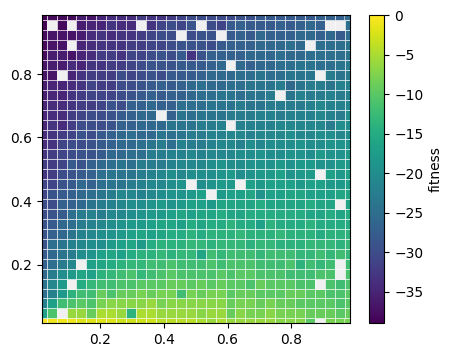

In [ ]:
plot_repertoire(state.repertoire)

elite fitness -28.0 | descriptors [0.203125 0.609375]


/tmp/ipykernel_3973362/4287446817.py:31: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].set(title="elite trajectory", xlabel="x", ylabel="y"); axes[0].set_aspect("equal"); axes[0].legend()


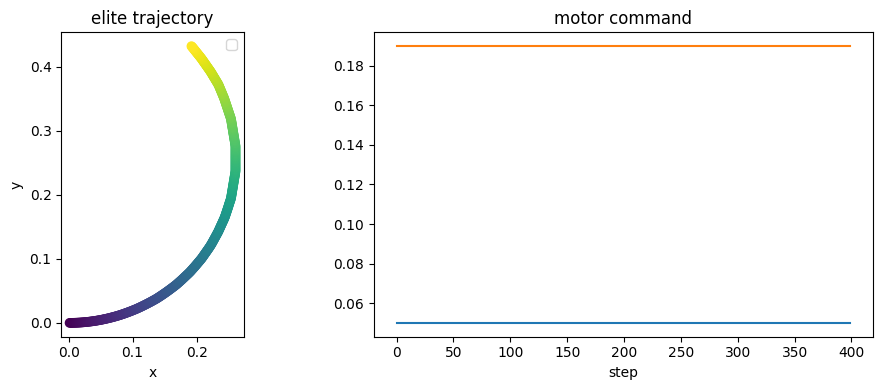

In [ ]:
occ = np.asarray(repertoire.is_occupied())
cen = np.asarray(repertoire.centroids)
fit = np.asarray(repertoire.fitnesses)

target_bd = np.asarray([0.2, 0.6])
best = int(jnp.argmin(np.where(repertoire.is_occupied(), np.linalg.norm(repertoire.descriptors - target_bd[None], axis=-1), jnp.inf)))
elite = jax.tree.map(lambda x: x[best], repertoire.genotypes)
print("elite fitness", float(fit[best]), "| descriptors", cen[best])

apply_fn, init_fn = make_apply_init(model)

def replay(genotype, key, steps=STEPS):
    net = _embodiable(init_fn(genotype, key))
    motor_state = MOTOR.init(net, key=key)
    body = Body(pos=jnp.zeros(2, jnp.float16),
                heading=jnp.float16(0.0), size=jnp.float16(BODY_SIZE))
    def step(carry, k):
        net, body, ms = carry
        net, _ = apply_fn(genotype, jnp.zeros((net.v.shape[0],)), net, k)
        action, _, ms, _ = MOTOR.decode(net, ms)
        body = MOTOR.move(action, body)
        return (net, body, ms), (body.pos, body.heading, action, net.v)
    _, (pos, heading, action, v) = jax.lax.scan(step, (net, body, motor_state), jr.split(key, steps))
    return net, Trajectory(pos=pos, heading=heading, action=action, v=v)

net, traj = eqx.filter_jit(replay)(elite, jr.key(np.random.randint(0,10000)))
pos = np.asarray(traj.pos, dtype=np.float32)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].scatter(pos[:, 0], pos[:, 1], c=np.arange(len(pos)))
axes[0].set(title="elite trajectory", xlabel="x", ylabel="y"); axes[0].set_aspect("equal"); axes[0].legend()
axes[1].plot(np.asarray(traj.action, dtype=np.float32)); axes[1].set(title="motor command", xlabel="step")
fig.tight_layout()

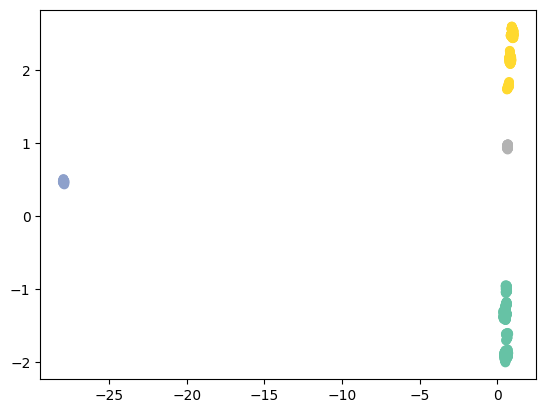

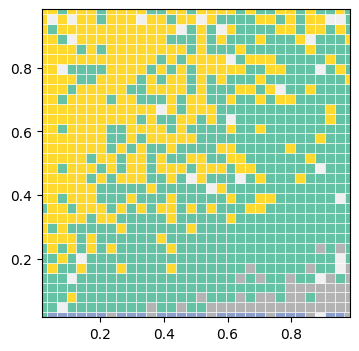

In [ ]:
all_genotypes = jax.tree.map(lambda x: x[repertoire.is_occupied()], repertoire.genotypes)

all_genotypes_flat = np.asarray(jax.vmap(lambda tree: ravel_pytree(tree)[0])(all_genotypes))

all_genotypes_flat.shape
pca = PCA(n_components=16)
pcs = pca.fit_transform(all_genotypes_flat)

kmeans = KMeans(n_clusters=4)
clusters = kmeans.fit_predict(pcs[:,:2])

plt.scatter(*pcs[:,:2].T, c=clusters, cmap="Set2")
plt.show()

new_fit = np.copy(fit)
new_fit[occ] = clusters
ax = plot_repertoire(repertoire.replace(fitnesses=new_fit), cmap="Set2", colorbar=False)

# Retina

In [ ]:
# ----------------------------------------------------------------------
# 1. knobs
# ----------------------------------------------------------------------

SEED = 0

REPERTOIRE = MapElitesRepertoire

CLASSES   = None     # (0,1) two-class; (3,5,8) harder subset; None -> all ten digits
N_CLASSES = 10 if CLASSES is None else len(CLASSES)
N_SAMPLES = N_CLASSES*1       # total images, balanced across classes (chance = 1/n_classes)

MODEL_KWARGS = dict(
    init_neurons=1, max_neurons=64, dev_iters=100,
    motor_genes=N_CLASSES,   # REQUIRED: one readout channel per class
    gene_noise_scale=0.0, position_noise_scale=0.0,
    synaptic_proteins=8, synaptic_genes=8,  regulatory_genes=8, 
    migratory_genes=4, 
    signalling_genes=8, signalling_proteins=8,
    wiring_model="mlp"
)

PRESENT_STEPS = 30          # ticks each image is held on the retina before readout
DESCRIPTORS   = ["random", "nb_neurons"]
GRID          = [64,64]
N             = 1024           # offspring / iteration; must divide across devices
TRAIN_STEPS   = 20_000
SIGMA_MUT, MUT_RATE = 0.03, 1.0
MAX_AGE = 32

# ----------------------------------------------------------------------
# 2. data + build
# ----------------------------------------------------------------------
images, labels = load_small_mnist(classes=CLASSES, n_samples=N_SAMPLES, seed=SEED)
print("data:", images.shape, "| classes:", N_CLASSES,
      "| chance = %.3f" % (1 / N_CLASSES))

genotype_fctry, model = make_rand_genotype_fctry(MODEL_KWARGS)

scoring_fn = make_rand_classification_scoring_fn(
    model, images, labels, n_classes=N_CLASSES,
    descriptors=DESCRIPTORS, present_steps=PRESENT_STEPS,
)
mutation_fn = ContinuousMutation(sigma_mut=SIGMA_MUT, mut_rate=MUT_RATE)

centroids = compute_euclidean_centroids(GRID, *descriptor_bounds(DESCRIPTORS))

data: (10, 8, 8) | classes: 10 | chance = 0.100


In [18]:
train = make_train_fn(genotype_fctry, scoring_fn, mutation_fn, centroids,
                      N=N, train_steps=TRAIN_STEPS, return_trace=True,
                      repertoire_kwargs=dict(max_age=MAX_AGE), nb_evals=1,
                      repertoire_cls=REPERTOIRE)
state, trace = train(jr.key(SEED))
repertoire = state.repertoire
print("final:", jax.tree.map(float, qd_metrics(repertoire)))

final: {'coverage': 0.9833984375, 'max_fitness': 0.800000011920929, 'mean_fitness': 0.5924032330513, 'nb_elites': 4028.0, 'qd_score': 2386.2001953125}


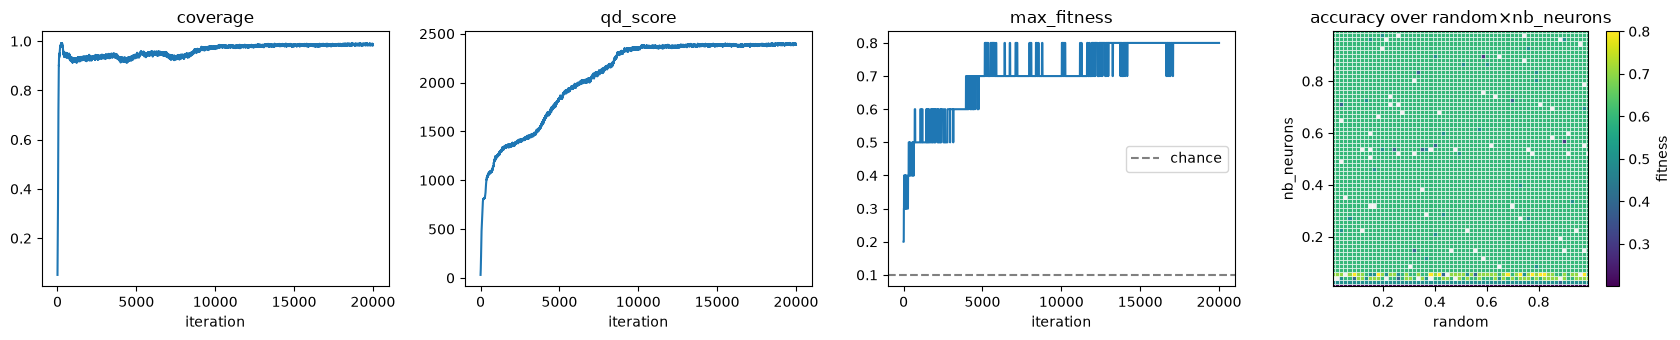

In [19]:
fig, axes = plt.subplots(1, 4, figsize=(17, 3.5))
for ax, k in zip(axes, ["coverage", "qd_score", "max_fitness"]):
    ax.plot(np.asarray(trace[k])); ax.set(xlabel="iteration", title=k)
axes[2].axhline(1 / N_CLASSES, ls="--", c="gray", label="chance"); axes[2].legend()
plot_repertoire(repertoire, ax=axes[3], descriptor_names=DESCRIPTORS,
                title="accuracy over %s" % "×".join(DESCRIPTORS))
fig.tight_layout()

stored accuracy 0.600 | descriptors [0.50781256 0.9921875 ]
re-grown accuracy 0.600
  digit 0: 1.000   (1 imgs)
  digit 1: 0.000   (1 imgs)
  digit 2: 1.000   (1 imgs)
  digit 3: 1.000   (1 imgs)
  digit 4: 0.000   (1 imgs)
  digit 5: 0.000   (1 imgs)
  digit 6: 1.000   (1 imgs)
  digit 7: 0.000   (1 imgs)
  digit 8: 1.000   (1 imgs)
  digit 9: 1.000   (1 imgs)


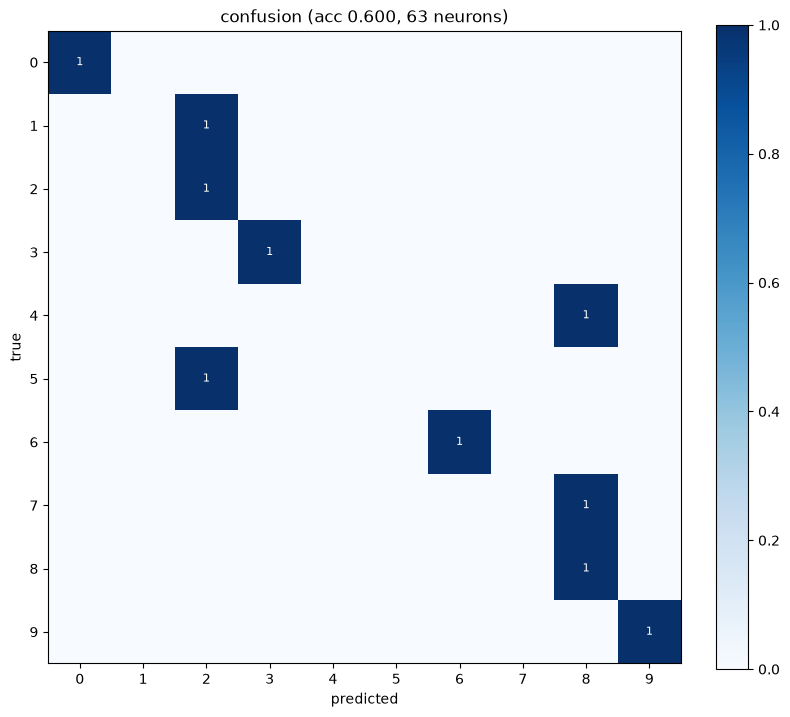

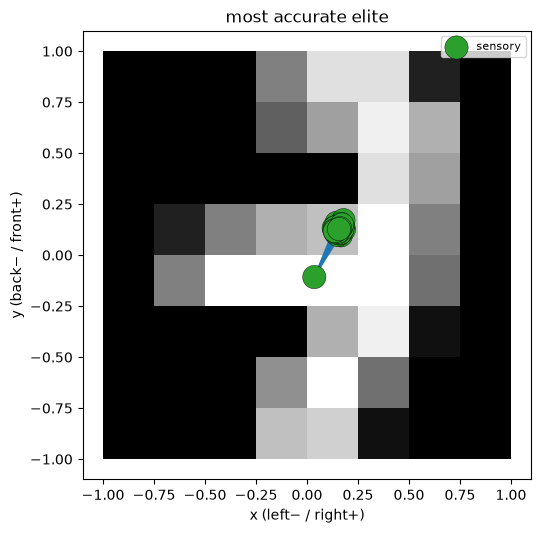

In [20]:
occ = np.asarray(repertoire.is_occupied())
cen = np.asarray(repertoire.centroids)
fit = np.asarray(repertoire.fitnesses)

target_bd = np.asarray([0.5, 1.])
#target_bd = repertoire.descriptors[np.argmax(repertoire.fitnesses)]
best = int(jnp.argmin(np.where(repertoire.is_occupied(), np.linalg.norm(repertoire.descriptors - target_bd[None], axis=-1), jnp.inf)))
elite = jax.tree.map(lambda x: x[best], repertoire.genotypes)
print("stored accuracy %.3f | descriptors %s"
      % (float(repertoire.fitnesses[best]), np.asarray(repertoire.centroids[best])))

# the scoring fn returns only aggregate accuracy, so replicate its readout to get predictions.
# NOTE: RAND development is stochastic (mitosis), so regrowing re-samples the phenotype —
# this accuracy is for a fresh growth and may differ slightly from the stored fitness.
apply_fn, init_fn = make_apply_init(model)
H, W = images.shape[1:]
retina = RetinaSensoryInterface(height=H, width=W)   # matches the scoring-fn default
no_internal = jnp.zeros(4)

def predict(genotype, key):
    net = init_fn(genotype, key)
    layout = retina.init(net, key)
    readout = net.m[:, :N_CLASSES] * net.mask[:, None]      # [N, n_classes], same as source
    def classify(image, k):
        def _step(state, kk):
            I, _, _, _ = retina.encode(Observation(env=image, internal=no_internal), state, layout)
            state, _ = apply_fn(genotype, I, state, kk)
            return state, None
        final, _ = jax.lax.scan(_step, net, jr.split(k, PRESENT_STEPS))
        return (final.v[:, None] * readout).sum(0)          # [n_classes]
    logits = jax.vmap(classify)(images, jr.split(key, images.shape[0]))
    return net, jnp.argmax(logits, -1)

elite_net, preds = eqx.filter_jit(predict)(elite, jr.key(np.random.randint(0, 10000)))
preds, truth = np.asarray(preds), np.asarray(labels)
class_names = list(range(10)) if CLASSES is None else list(CLASSES)

print("re-grown accuracy %.3f" % (preds == truth).mean())
for i, name in enumerate(class_names):
    m = truth == i
    print(f"  digit {name}: {(preds[m] == i).mean():.3f}   ({int(m.sum())} imgs)")

# confusion matrix
K = N_CLASSES
conf = np.zeros((K, K), int); np.add.at(conf, (truth, preds), 1)
fig, ax = plt.subplots(figsize=(0.6 * K + 2, 0.6 * K + 1.5))
im = ax.imshow(conf, cmap="Blues")
ax.set(xticks=range(K), yticks=range(K), xticklabels=class_names, yticklabels=class_names,
       xlabel="predicted", ylabel="true",
       title="confusion (acc %.3f, %d neurons)" % ((preds == truth).mean(), int(elite_net.mask.sum())))
for a in range(K):
    for b in range(K):
        if conf[a, b]:
            ax.text(b, a, conf[a, b], ha="center", va="center", fontsize=8,
                    color="white" if conf[a, b] > conf.max() / 2 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
fig.tight_layout()

# ----------------------------------------------------------------------
# 5b. draw the elite network (self-contained; replaces render_network)
#     green = sensory neuron (sees the retina); node size = motor readout weight |m|
# ----------------------------------------------------------------------
def draw_network(net, ax=None, draw_edges=True, edge_min=1e-3):
    x = np.asarray(net.x); mask = np.asarray(net.mask).astype(bool)
    s = np.asarray(net.s); m = np.asarray(net.m)
    s1 = s.mean(-1) if s.ndim == 2 else s          # scalar sensitivity per neuron
    m1 = m[:, :N_CLASSES].sum(-1) if m.ndim == 2 else m   # total readout drive per neuron
    if ax is None:
        _, ax = plt.subplots(figsize=(5.5, 5.5))

    if draw_edges:
        Wm = np.asarray(net.W); idx = np.flatnonzero(mask)
        wmax = np.abs(Wm[np.ix_(idx, idx)]).max() or 1.0
        for i in idx:
            for j in idx:
                w = Wm[i, j]
                if abs(w) < edge_min:
                    continue
                ax.plot([x[i, 0], x[j, 0]], [x[i, 1], x[j, 1]],
                        color="tab:red" if w > 0 else "tab:blue",
                        alpha=min(abs(w) / wmax, 1.0) * 0.5, lw=0.6, zorder=1)

    is_sensor = (s1 > retina.sensor_expression_threshold) & mask
    size = 20 + 260 * np.clip(np.abs(m1), 0, 1)     # bigger = drives the class readout more
    for sel, color, label in [(mask & ~is_sensor, "lightgray", "non-sensory"),
                              (mask &  is_sensor, "tab:green", "sensory")]:
        if sel.any():
            ax.scatter(x[sel, 0], x[sel, 1], s=size[sel], c=color, label=label,
                       edgecolors="k", linewidths=0.3, zorder=2)
    ax.set(xlim=(-1.1, 1.1), ylim=(-1.1, 1.1),
           xlabel="x (left− / right+)", ylabel="y (back− / front+)")
    ax.set_aspect("equal"); ax.legend(fontsize=8, loc="upper right")
    return ax

fig, ax = plt.subplots(figsize=(5.5, 5.5))
draw_network(elite_net, ax=ax)
ax.imshow(images[np.random.choice(len(images))], extent=[-1,1,-1,1], cmap="gray")
ax.set_title("most accurate elite")
fig.tight_layout()

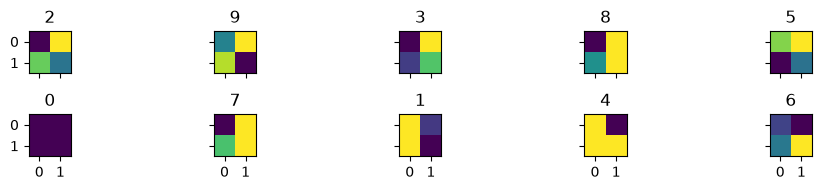

In [34]:
fig, axs = plt.subplots(2,5, figsize=(10,2), sharex=True, sharey=True)
axs = axs.reshape(-1)
for i, (image, label) in enumerate(zip(images, labels)):
    sub = image[3:5][:,3:5]
    axs[i].imshow(sub)
    axs[i].set_title(label)
fig.tight_layout()
plt.show()


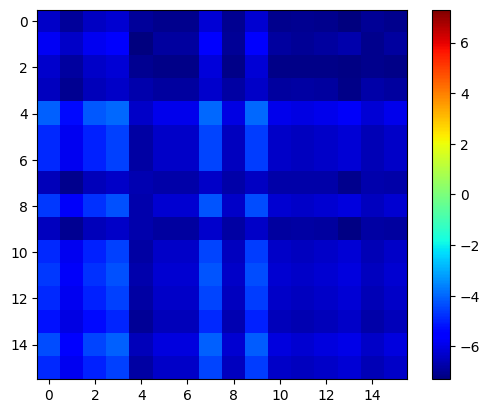

In [31]:
W = elite_net.W[elite_net.mask][:,elite_net.mask]
wmax = np.max(np.abs(W))
plt.imshow(elite_net.W[elite_net.mask][:,elite_net.mask], cmap="jet", vmin=-wmax, vmax=wmax)
plt.colorbar()

Array([[0.]], dtype=float32)

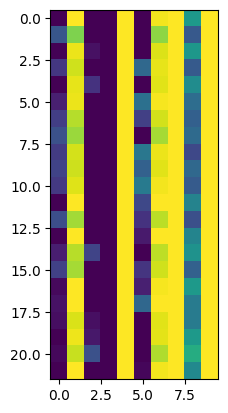

In [61]:
m = elite_net.m
mask = elite_net.mask

plt.imshow(m[mask][:,:N_CLASSES])

In [ ]:
with open(f"data/rand_qd/mnist_{DESCRIPTORS[0]}_{DESCRIPTORS[1]}_{TRAIN_STEPS}.pkl", "wb") as file:
    pickle.dump([state, trace], file)

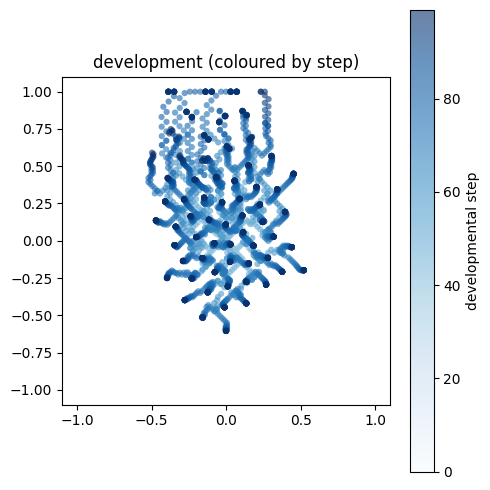

In [51]:
_, static = eqx.partition(model, eqx.is_array)
elite_model = eqx.combine(elite, static)          # genotype -> runnable RAND_CTRNN

embryo = elite_model.init_embryo(jr.key(0))
final_state, dev_trace = eqx.filter_jit(elite_model.do_migration)(embryo, jr.key(2))
#   NOTE: use eqx.filter_jit, not jax.jit -- the module holds arrays and won't hash.

fig, axes = plt.subplots(1, 1, figsize=(5,5))
render_developmental_trajectory(dev_trace["state"], ax=axes, every=1,
                                title="development (coloured by step)", cmap="Blues", s=20)
#render_network(elite_model.make_network(final_state), ax=axes[1])
fig.tight_layout()